<div style="display: flex; align-items: center; justify-content: space-between">
    <div>
        <img src="https://raw.githubusercontent.com/sebastianVP/RADAR_AMISR/refs/heads/main/igp_logo.jpeg"
         alt="LOGO IGP" width="200" height="200" style="margin-left: 20px; border-radius: 10px;" align = "right">
        <h1 style="color: #800020;  font-weight: bold; margin-bottom: 10px; font-family: Arial, sans-serif;">
          <font color="#7F000E">
            Maestría de Ciencias de la Computación UNI-IGP
          </font>
        </h1>
        <h2 style="color: #800020;font-weight: bold; max-width: 750px; font-family: Arial, sans-serif;">
          <strong><font color="#7F000E" size=5 >
            Desarrollo de sistema de pronóstico de centelleo ionosférico sobre el Perú para alerta de
            perturbaciones en señales satelitales
          </font ></strong>
        </h2>
    </div>
</div>
<div>
    <p style="margin-bottom: 5px;">
    <strong>
    <font color="#7F000E" size=4 >Avance de Tesis </strong></p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Alumno:</strong></font>
    <font color="#7F000E"> Alexander Valdez Portocarrero</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Código:</strong> 20207072E</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Fecha:</strong>  25/11/2025</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong> Ciclo 2025-2</strong></p>
</div>

---

# **🧠 PROYECTO:**
- Tema: Aplicación de técnicas de aprendizaje profundo (LSTM) para la predicción del índice S4 a partir de parámetros ionosféricos y geomagnéticos.

# **📦 1. Importación y carga de datos**

In [1]:
# =====================================
# 1. Importar librerías necesarias
# =====================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from datetime import timedelta
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense , Dropout
import tensorflow.keras.backend as K
import time
import os

2025-11-25 14:20:14.541797: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-25 14:20:14.778943: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764098414.871851 2175371 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764098414.901079 2175371 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764098415.103248 2175371 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

# **📂 2. Lectura y exploración inicial del dataset**

In [3]:
# =====================================
# 2. Cargar el dataset base
# =====================================

PATH = "/home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook"
file = "df_FINAL.csv"

filename =  os.path.join(PATH,file)
df_FINAL =  pd.read_csv(filename)

# Convertir columna de tiempo a formato datetime
df_FINAL["Tiempo"] = pd.to_datetime(df_FINAL["Tiempo"])
# =====================================
# 3. Identificar días con cintilación
# =====================================

# Extraer solo la fecha
df_FINAL["dias"] = df_FINAL["Tiempo"].dt.date

# Número total de días en el dataset
print(f"Número total de días: {df_FINAL['dias'].nunique()}")

# Filtrar días donde hubo cintilación (Cintilacion == 1)
df_con_cintilacion = df_FINAL[df_FINAL['Cintilacion'] == 1].copy()
df_con_cintilacion["Fecha"] = df_con_cintilacion["Tiempo"].dt.date

# Contar días únicos con cintilación
dias_unicos = pd.Series(df_con_cintilacion["Fecha"].unique())
print(f"Número de días con cintilación: {dias_unicos.nunique()}")


Número total de días: 148
Número de días con cintilación: 29


In [5]:
# Lectura del archivo
file = "df_FINAL.csv"

filename =  os.path.join(PATH,file)
df =  pd.read_csv(filename)
df["Tiempo"] = pd.to_datetime(df["Tiempo"])
# Establecer índice temporal
df_new = df.set_index("Tiempo").copy()
# Convertir fechas únicas a formato datetime
dias_unicos = pd.to_datetime(dias_unicos)

# Filtrar registros correspondientes a los días con cintilación
df_FINAL_CINT = df_new[df_new.index.normalize().isin(dias_unicos)].reset_index()

print(f"Filas finales con cintilación: {len(df_FINAL_CINT)}")

Filas finales con cintilación: 40838


In [7]:
df_FINAL_CINT.head()

,Tiempo,Cintilacion,Azimuth,Elevacion,TEC,ROTEC,ROTI,Kp_Index,Dst_Index,ap_Index,f10.7_Index,AE_Index,S4
0,2025-01-28 00:01:00,0.0,140.0,52.0,71.649570,-0.006873,0.010323,20.0,-0.016667,7.0,166.3,97.8,0.093
1,2025-01-28 00:02:00,0.0,226.0,43.0,71.544307,-0.006454,0.010285,20.0,-0.033333,7.0,166.3,98.6,0.080
2,2025-01-28 00:03:00,0.0,227.0,44.0,71.439044,-0.006034,0.010248,20.0,-0.050000,7.0,166.3,99.4,0.122
3,2025-01-28 00:04:00,0.0,138.0,53.0,71.333781,-0.005614,0.010211,20.0,-0.066667,7.0,166.3,100.2,0.080
4,2025-01-28 00:05:00,0.0,137.0,54.0,71.228518,-0.005194,0.010174,20.0,-0.083333,7.0,166.3,101.0,0.086


In [9]:
df_FINAL_CINT.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40838 entries, 0 to 40837
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Tiempo       40838 non-null  datetime64[ns]
 1   Cintilacion  40838 non-null  float64       
 2   Azimuth      40838 non-null  float64       
 3   Elevacion    40838 non-null  float64       
 4   TEC          40838 non-null  float64       
 5   ROTEC        40838 non-null  float64       
 6   ROTI         40838 non-null  float64       
 7   Kp_Index     40838 non-null  float64       
 8   Dst_Index    40838 non-null  float64       
 9   ap_Index     40838 non-null  float64       
 10  f10.7_Index  40838 non-null  float64       
 11  AE_Index     40838 non-null  float64       
 12  S4           40838 non-null  float64       
dtypes: datetime64[ns](1), float64(12)
memory usage: 4.1 MB


In [11]:
# ====================================================
# 🔹 CARGA Y PREPARACIÓN DE DATOS
# ====================================================
# Copia del DataFrame original
data = df_FINAL_CINT.copy()

# Eliminar columnas no relevantes
# data = data.drop(columns=["Cintilacion", "Fecha", "Azimuth", "Elevacion"])
data = data.drop(columns=["Cintilacion", "Azimuth", "Elevacion"])

# Definir índice temporal
data["Tiempo"] = pd.to_datetime(data["Tiempo"])
data.set_index("Tiempo", inplace=True)

In [13]:
data.head()

,TEC,ROTEC,ROTI,Kp_Index,Dst_Index,ap_Index,f10.7_Index,AE_Index,S4
Tiempo,,,,,,,,,
2025-01-28 00:01:00,71.649570,-0.006873,0.010323,20.0,-0.016667,7.0,166.3,97.8,0.093
2025-01-28 00:02:00,71.544307,-0.006454,0.010285,20.0,-0.033333,7.0,166.3,98.6,0.080
2025-01-28 00:03:00,71.439044,-0.006034,0.010248,20.0,-0.050000,7.0,166.3,99.4,0.122
2025-01-28 00:04:00,71.333781,-0.005614,0.010211,20.0,-0.066667,7.0,166.3,100.2,0.080
2025-01-28 00:05:00,71.228518,-0.005194,0.010174,20.0,-0.083333,7.0,166.3,101.0,0.086



🚀 Entrenando modelo (Ventana=60, Horizonte=20)...


I0000 00:00:1764098445.020399 2175371 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1109 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9
/home/soporte/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1764098446.600494 2175544 cuda_dnn.cc:529] Loaded cuDNN version 90501


255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

🚀 Entrenando modelo (Ventana=60, Horizonte=30)...


/home/soporte/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

🚀 Entrenando modelo (Ventana=60, Horizonte=40)...


...

254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

🚀 Entrenando modelo (Ventana=180, Horizonte=40)...


/home/soporte/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

🚀 Entrenando modelo (Ventana=180, Horizonte=60)...


/home/soporte/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

⏱️ Tiempo total de experimentación: 6.89 minutos

📊 Resultados comparativos:
    Ventana (min)  Horizonte (min)       MAE      RMSE      MAPE
8             180               20  0.024328  0.042511  8.047907
4             120               20  0.024392  0.042888  5.217936
5             120               30  0.027743  0.044306  9.896344
1              60               30  0.026325  0.045148  7.749572
0              60               20  0.025857  0.046166  6.338206
9             180               30  0.028702  0.047109  9.118784
6             120               40  0.028171  0.048087  6.649892
2              60               40  0.027623  0.048981  9.548570
10            180               40  0.028981  0.049129  6.801478
11            180               60  0.027733  0.050919  6.949168
7             120               60  0.028289  0.051744  4.522837
3              60               60  0.029539  0.052684  7.236656


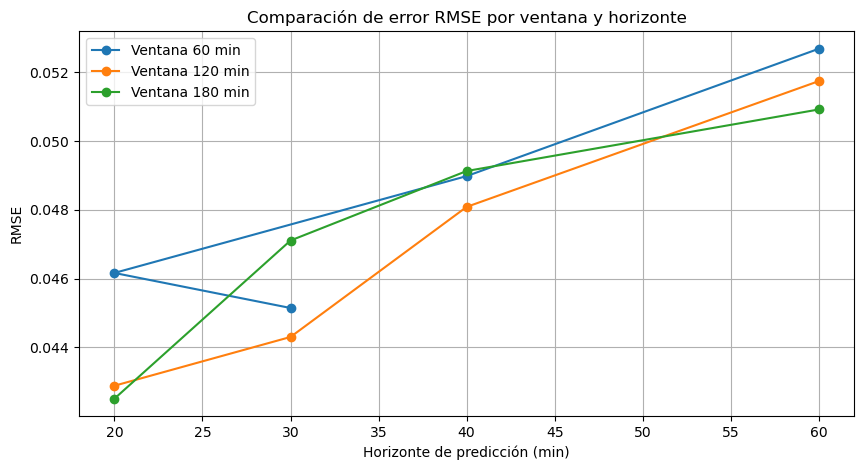


💾 Resultados guardados en 'resultados_LSTM_experimentos.csv'


In [15]:
# ====================================================
# 🔹 IMPORTACIÓN DE LIBRERÍAS
# ====================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import tensorflow.keras.backend as K
import time

# ====================================================
# 🔹 CONFIGURACIÓN GLOBAL
# ====================================================
data = df_FINAL_CINT.copy()
#data = data.drop(columns=["Cintilacion", "Fecha", "Azimuth", "Elevacion"])
data = data.drop(columns=["Cintilacion", "Azimuth", "Elevacion"])

data["Tiempo"] = pd.to_datetime(data["Tiempo"])
data.set_index("Tiempo", inplace=True)

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)
df_scaled = pd.DataFrame(data_scaled, columns=data.columns, index=data.index)

target_index = data.columns.get_loc("S4")

# ====================================================
# 🔹 FUNCIONES AUXILIARES
# ====================================================

def create_sequences(data, n_steps, horizon, index=None):
    X, y, times = [], [], []
    for i in range(len(data) - n_steps - horizon):
        X.append(data[i:i+n_steps])
        y.append(data[i+n_steps+horizon, -1])
        if index is not None:
            times.append(index[i+n_steps+horizon])
    return np.array(X), np.array(y), np.array(times)


def peak_loss(y_true, y_pred):
    error = K.abs(y_true - y_pred)
    weight = K.cast(y_true > 0.5, "float32") * 3.0 + 1.0
    return K.mean(weight * error)


def train_lstm(df_scaled, n_steps, horizon, epochs=5, batch_size=32):
    X, y, times = create_sequences(df_scaled.values, n_steps, horizon, df_scaled.index)
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    time_train, time_test = times[:split], times[split:]

    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(n_steps, df_scaled.shape[1])),
        Dropout(0.2),
        LSTM(64),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss=peak_loss)
    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2, verbose=0)

    y_pred = model.predict(X_test)

    # Invertir escala solo para S4
    s4_scaler = MinMaxScaler()
    s4_scaler.min_, s4_scaler.scale_ = scaler.min_[target_index], scaler.scale_[target_index]
    y_test_original = y_test * s4_scaler.scale_ + s4_scaler.min_
    y_pred_original = y_pred * s4_scaler.scale_ + s4_scaler.min_

    mae = mean_absolute_error(y_test_original, y_pred_original)
    rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
    mape = mean_absolute_percentage_error(y_test_original, y_pred_original)

    return mae, rmse, mape, y_test_original, y_pred_original


# ====================================================
# 🔹 EXPERIMENTOS AUTOMÁTICOS
# ====================================================

ventanas = [60, 120, 180]       # minutos pasados (1h, 2h, 3h)
horizontes = [20, 30, 40, 60]   # minutos futuros
resultados = []

start = time.time()
for n_steps in ventanas:
    for horizon in horizontes:
        print(f"\n🚀 Entrenando modelo (Ventana={n_steps}, Horizonte={horizon})...")
        mae, rmse, mape, y_real, y_pred = train_lstm(df_scaled, n_steps, horizon, epochs=5)
        resultados.append({
            "Ventana (min)": n_steps,
            "Horizonte (min)": horizon,
            "MAE": mae,
            "RMSE": rmse,
            "MAPE": mape
        })
end = time.time()

print(f"\n⏱️ Tiempo total de experimentación: {(end - start)/60:.2f} minutos")

# ====================================================
# 🔹 ANÁLISIS DE RESULTADOS
# ====================================================
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values(by="RMSE", ascending=True)
print("\n📊 Resultados comparativos:")
print(df_resultados)

# ====================================================
# 🔹 VISUALIZACIÓN DE RENDIMIENTO
# ====================================================
plt.figure(figsize=(10, 5))
for n_steps in ventanas:
    subset = df_resultados[df_resultados["Ventana (min)"] == n_steps]
    plt.plot(subset["Horizonte (min)"], subset["RMSE"], marker="o", label=f"Ventana {n_steps} min")

plt.title("Comparación de error RMSE por ventana y horizonte")
plt.xlabel("Horizonte de predicción (min)")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

# ====================================================
# 🔹 EXPORTAR RESULTADOS
# ====================================================
df_resultados.to_csv("resultados_LSTM_experimentos.csv", index=False)
print("\n💾 Resultados guardados en 'resultados_LSTM_experimentos.csv'")


## **MODELO AVANZADO EN TESIS**
- Robusto
- Profesional
- GPU-Friendly

In [66]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, LSTM, Bidirectional, Conv1D, LayerNormalization,
    Dropout, Dense
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import AdamW
#import tensorflow_addons as tfa

def peak_loss_deriv(y_true, y_pred):
    """
    Peak Loss basada en derivadas (la más científica)
    Los picos no son solo valores grandes:
    👉 son puntos donde la derivada cambia fuerte.
    
    Entonces penalizamos dos cosas:
    1️⃣ error en amplitud
    2️⃣ error en forma (derivada)
    """
    # Error base
    error = K.abs(y_true - y_pred)

    # Derivadas (diferencia temporal)
    dy_true = y_true[:, 1:] - y_true[:, :-1]
    dy_pred = y_pred[:, 1:] - y_pred[:, :-1]

    # Error en derivada (forma)
    deriv_error = K.abs(dy_true - dy_pred)

    # Peso adaptativo: amplifica donde la derivada real es grande = picos
    peak_weight = 1.0 + 5.0 * K.abs(dy_true)

    # Combinación final
    return K.mean(peak_weight[:, :-1] * error[:, :-1] + 0.5 * deriv_error)

def peak_loss_altos_S4(y_true, y_pred, gamma=2.0):
    error = K.abs(y_true - y_pred)
    weight = 1.0 + 5.0 * K.square(y_true)   # más suave que el corte 0.5
    return K.mean(weight * error)

def train_lstm_avanzado(df_scaled, n_steps, horizon, epochs=30, batch_size=32):

    # Crear secuencias
    X, y, times = create_sequences(df_scaled.values, n_steps, horizon, df_scaled.index)
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # ----------------------------
    # 🔥 ARQUITECTURA ROBUSTA
    # ----------------------------
    model = Sequential([
        Input(shape=(n_steps, df_scaled.shape[1])),

        # 1) Extracción local de patrones
        Conv1D(filters=32, kernel_size=3, activation="relu", padding="causal"),
        LayerNormalization(),

        # 2) Captura de dependencias largas
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.3),
        LayerNormalization(),

        # 3) Resumen secuencial
        LSTM(32),
        Dropout(0.2),

        # 4) Capa final
        Dense(1, dtype="float32")  # salida siempre float32
    ])

    # ----------------------------
    # 🔥 OPTIMIZADOR MODERNO
    # ----------------------------
    #optimizer = tfa.optimizers.AdamW(
    #    learning_rate=1e-3,
    #    weight_decay=1e-4
    #)
    optimizer = AdamW(learning_rate=1e-3, weight_decay=1e-4)

    #model.compile(optimizer=optimizer, loss=peak_loss)
    #model.compile(optimizer=optimizer, loss=peak_loss_deriv)
    model.compile(optimizer=optimizer, loss=peak_loss_altos_S4)

    # ----------------------------
    # 🔥 EARLY STOPPING
    # ----------------------------
    es = EarlyStopping(
        patience=5,
        monitor="val_loss",
        restore_best_weights=True
    )

    model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.1,
        callbacks=[es],
        verbose=0
    )

    # ----------------------------
    # 🔥 PREDICCIÓN E INVERTIR ESCALA
    # ----------------------------
    y_pred = model.predict(X_test, verbose=0)

    s4_scaler = MinMaxScaler()
    s4_scaler.min_, s4_scaler.scale_ = scaler.min_[target_index], scaler.scale_[target_index]

    y_test_original = y_test * s4_scaler.scale_ + s4_scaler.min_
    y_pred_original = y_pred * s4_scaler.scale_ + s4_scaler.min_

    # ----------------------------
    # 🔥 MÉTRICAS
    # ----------------------------
    mae = mean_absolute_error(y_test_original, y_pred_original)
    rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
    mape = mean_absolute_percentage_error(y_test_original, y_pred_original)

    # Limpiar GPU
    tf.keras.backend.clear_session()

    return mae, rmse, mape, y_test_original, y_pred_original



🚀 Entrenando modelo (Ventana=60, Horizonte=20)...

🚀 Entrenando modelo (Ventana=60, Horizonte=30)...

🚀 Entrenando modelo (Ventana=60, Horizonte=40)...

🚀 Entrenando modelo (Ventana=60, Horizonte=60)...

🚀 Entrenando modelo (Ventana=120, Horizonte=20)...

🚀 Entrenando modelo (Ventana=120, Horizonte=30)...

🚀 Entrenando modelo (Ventana=120, Horizonte=40)...

🚀 Entrenando modelo (Ventana=120, Horizonte=60)...

🚀 Entrenando modelo (Ventana=180, Horizonte=20)...

🚀 Entrenando modelo (Ventana=180, Horizonte=30)...

🚀 Entrenando modelo (Ventana=180, Horizonte=40)...

🚀 Entrenando modelo (Ventana=180, Horizonte=60)...

⏱️ Tiempo total de experimentación: 9.56 minutos

📊 Resultados comparativos Modelos Avanzados:
    Ventana (min)  Horizonte (min)       MAE      RMSE      MAPE  \
4             120               20  0.025153  0.043549  7.797353   
5             120               30  0.024680  0.043624  7.754282   
0              60               20  0.025552  0.044071  8.619662   
1           

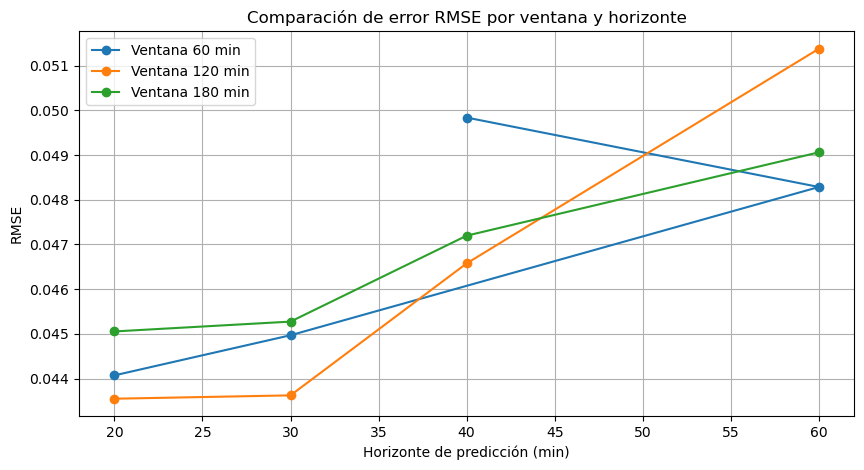


💾 Resultados guardados en 'resultados_LSTM_experimentos_avanzados.csv'


In [68]:
# ====================================================
# 🔹 EXPERIMENTOS AUTOMÁTICOS
# ====================================================

ventanas = [60, 120, 180]       # minutos pasados (1h, 2h, 3h)
horizontes = [20, 30, 40, 60]   # minutos futuros
resultados = []

start = time.time()
for n_steps in ventanas:
    for horizon in horizontes:
        print(f"\n🚀 Entrenando modelo (Ventana={n_steps}, Horizonte={horizon})...")
        mae, rmse, mape, y_real, y_pred = train_lstm_avanzado(df_scaled, n_steps, horizon, epochs=5)
        resultados.append({
            "Ventana (min)": n_steps,
            "Horizonte (min)": horizon,
            "MAE": mae,
            "RMSE": rmse,
            "MAPE": mape,
            "y_real": y_real,      # 👈 guardamos
            "y_pred": y_pred       # 👈 guardamos
        })
end = time.time()

print(f"\n⏱️ Tiempo total de experimentación: {(end - start)/60:.2f} minutos")

# ====================================================
# 🔹 ANÁLISIS DE RESULTADOS
# ====================================================
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values(by="RMSE", ascending=True)
print("\n📊 Resultados comparativos Modelos Avanzados:")
print(df_resultados)

# ====================================================
# 🔹 VISUALIZACIÓN DE RENDIMIENTO
# ====================================================
plt.figure(figsize=(10, 5))
for n_steps in ventanas:
    subset = df_resultados[df_resultados["Ventana (min)"] == n_steps]
    plt.plot(subset["Horizonte (min)"], subset["RMSE"], marker="o", label=f"Ventana {n_steps} min")

plt.title("Comparación de error RMSE por ventana y horizonte")
plt.xlabel("Horizonte de predicción (min)")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

# ====================================================
# 🔹 EXPORTAR RESULTADOS
# ====================================================
df_resultados.to_csv("resultados_LSTM_experimentos_avanzados.csv", index=False)
print("\n💾 Resultados guardados en 'resultados_LSTM_experimentos_avanzados.csv'")

## **SELECCIONAMOS LOS 5 MEJORES MODELOS**

In [72]:
import pandas as pd

# Convertir resultados a DataFrame para revisar métricas
df_res = pd.DataFrame([{
    "Ventana (min)": r["Ventana (min)"],
    "Horizonte (min)": r["Horizonte (min)"],
    "MAE": r["MAE"],
    "RMSE": r["RMSE"],
    "MAPE": r["MAPE"]
} for r in resultados])

df_res_sorted = df_res.sort_values(by="MAE").head(5)
df_res_sorted

,Ventana (min),Horizonte (min),MAE,RMSE,MAPE
5,120,30,0.024680,0.043624,7.754282
1,60,30,0.025135,0.044969,6.647739
4,120,20,0.025153,0.043549,7.797353
9,180,30,0.025318,0.045274,7.508760
0,60,20,0.025552,0.044071,8.619662


## **GRAFICAR LOS TOP 5 RESULTADOS**


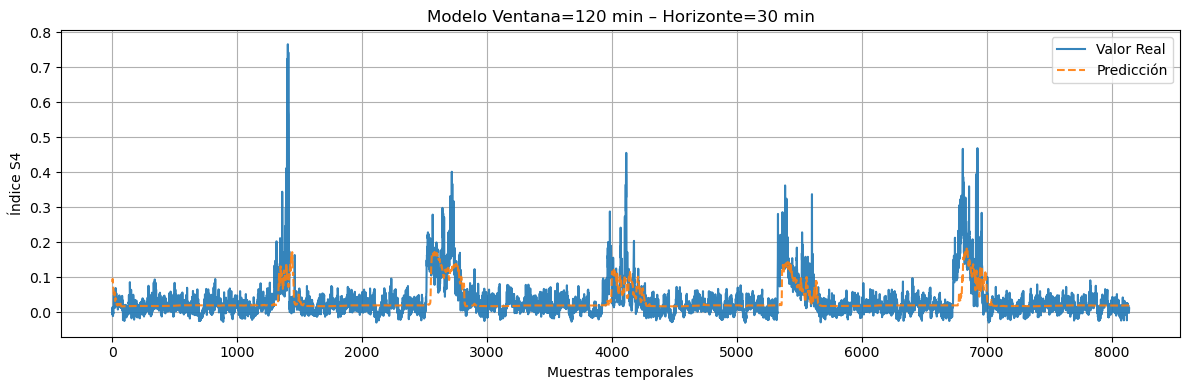

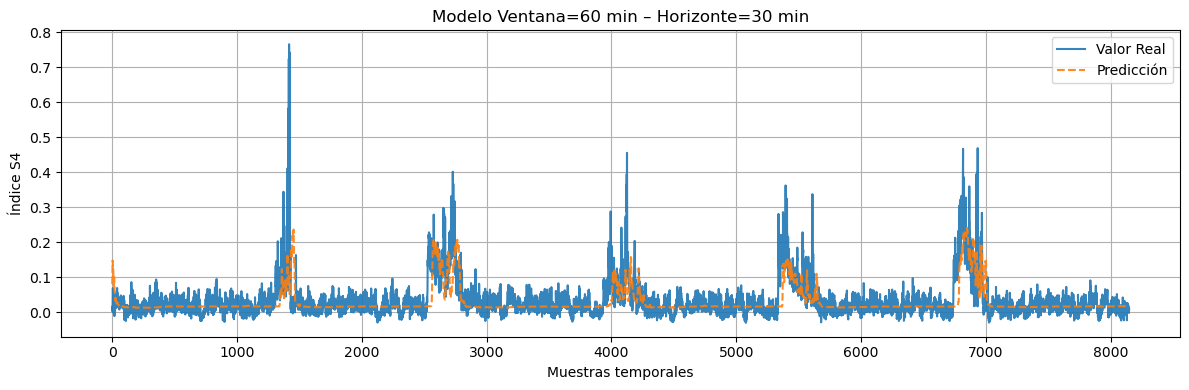

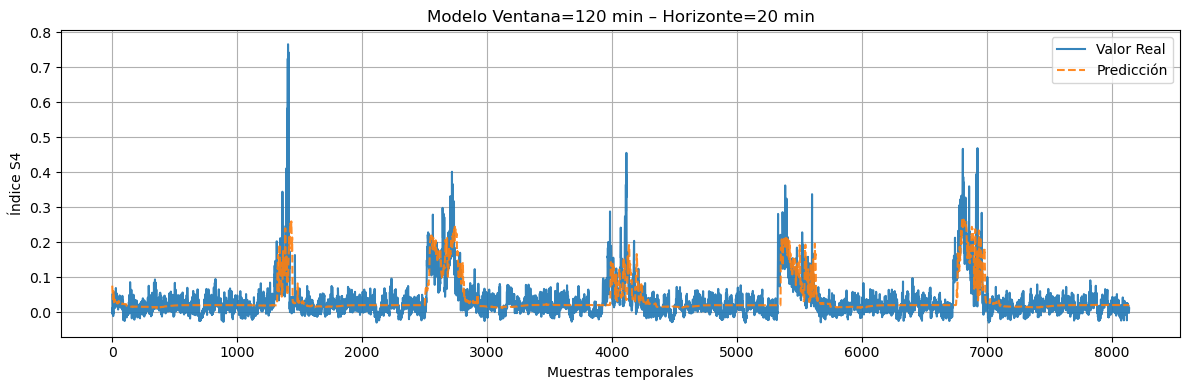

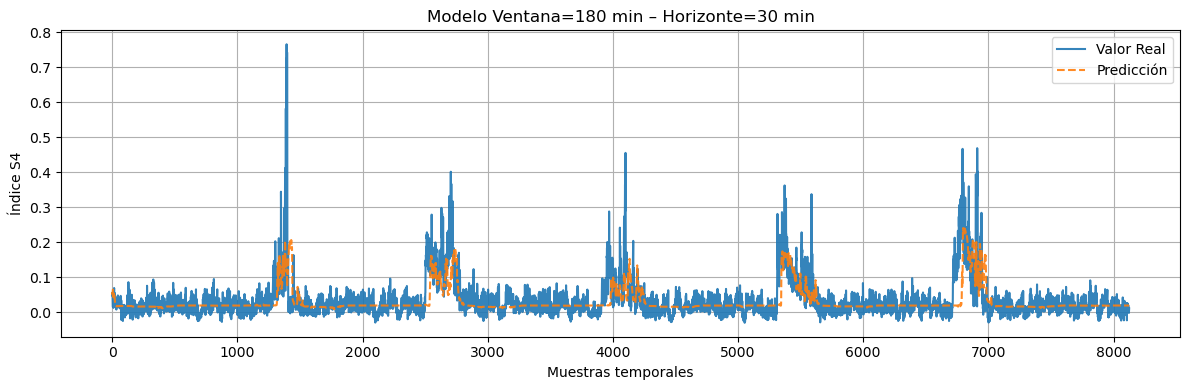

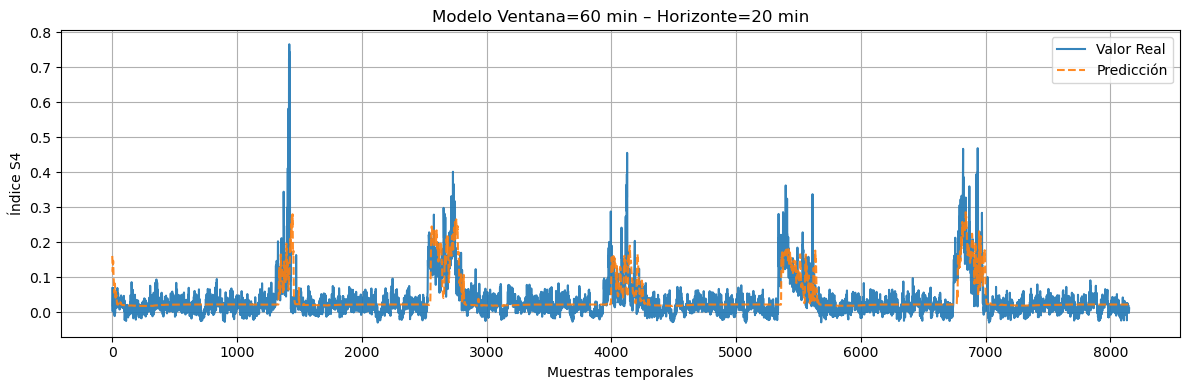

In [76]:
import matplotlib.pyplot as plt

for i, row in df_res_sorted.iterrows():
    r = resultados[i]
    y_real = r["y_real"]
    y_pred = r["y_pred"]

    plt.figure(figsize=(12, 4))
    
    plt.plot(y_real, label="Valor Real", alpha=0.9)
    plt.plot(y_pred, label="Predicción", linestyle="--", alpha=0.9)

    plt.title(f"Modelo Ventana={r['Ventana (min)']} min – Horizonte={r['Horizonte (min)']} min")
    plt.xlabel("Muestras temporales")
    plt.ylabel("Índice S4")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
